# Movie Rental Data Warehouse 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

## 1. Database Connections

In [2]:
MYSQL_USER = "root"
MYSQL_PASSWORD = "12345"   # change if your password is different
MYSQL_HOST = "localhost"
MYSQL_PORT = "3306"
SOURCE_DB = "sakila"
DW_DB = "rental_dw"

source_engine = create_engine(f"mysql+mysqlconnector://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{SOURCE_DB}")
server_engine = create_engine(f"mysql+mysqlconnector://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}")

with server_engine.begin() as conn:
    conn.execute(text(f"DROP DATABASE IF EXISTS {DW_DB};"))
    conn.execute(text(f"CREATE DATABASE {DW_DB};"))

dw_engine = create_engine(f"mysql+mysqlconnector://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{DW_DB}")
print("Connections ready and rental_dw recreated.")

Connections ready and rental_dw recreated.


## 2. Create Data Warehouse Tables

In [3]:
create_tables_sql = """
SET FOREIGN_KEY_CHECKS = 0;
DROP TABLE IF EXISTS Fact_Payment;
DROP TABLE IF EXISTS Fact_Rental;
DROP TABLE IF EXISTS Fact_Inventory;
DROP TABLE IF EXISTS ETL_Reject_Log;
DROP TABLE IF EXISTS DQ_Rules;
DROP TABLE IF EXISTS Dim_Staff;
DROP TABLE IF EXISTS Dim_Store;
DROP TABLE IF EXISTS Dim_Film;
DROP TABLE IF EXISTS Dim_Customer;
DROP TABLE IF EXISTS Dim_Date;
SET FOREIGN_KEY_CHECKS = 1;

CREATE TABLE Dim_Date (
    date_key INT PRIMARY KEY,
    full_date DATE,
    day_of_week VARCHAR(10),
    day_of_month INT,
    month_number INT,
    month_name VARCHAR(10),
    quarter INT,
    year INT,
    is_weekend TINYINT(1),
    season VARCHAR(10)
);

CREATE TABLE Dim_Customer (
    customer_key INT PRIMARY KEY,
    customer_id SMALLINT UNSIGNED NOT NULL,
    full_name VARCHAR(100),
    email VARCHAR(100),
    city VARCHAR(50),
    country VARCHAR(50),
    postal_code VARCHAR(15),
    active_status VARCHAR(10),
    create_date DATE,
    UNIQUE KEY uk_dim_customer_id (customer_id)
);

CREATE TABLE Dim_Film (
    film_key INT PRIMARY KEY,
    film_id SMALLINT UNSIGNED NOT NULL,
    title VARCHAR(255),
    description TEXT,
    release_year INT,
    language VARCHAR(50),
    rental_duration INT,
    rental_rate DECIMAL(5,2),
    length_minutes INT,
    rating VARCHAR(10),
    category VARCHAR(50),
    special_features VARCHAR(255),
    UNIQUE KEY uk_dim_film_id (film_id)
);

CREATE TABLE Dim_Store (
    store_key INT PRIMARY KEY,
    store_id TINYINT UNSIGNED NOT NULL,
    store_address VARCHAR(100),
    city VARCHAR(50),
    country VARCHAR(50),
    postal_code VARCHAR(15),
    UNIQUE KEY uk_dim_store_id (store_id)
);

CREATE TABLE Dim_Staff (
    staff_key INT PRIMARY KEY,
    staff_id TINYINT UNSIGNED NOT NULL,
    full_name VARCHAR(100),
    email VARCHAR(100),
    store_id TINYINT UNSIGNED,
    active_status VARCHAR(10),
    UNIQUE KEY uk_dim_staff_id (staff_id)
);

CREATE TABLE Fact_Inventory (
    inventory_key INT PRIMARY KEY,
    inventory_id MEDIUMINT UNSIGNED NOT NULL,
    film_key INT,
    store_key INT,
    inventory_date_key INT,
    inventory_count INT DEFAULT 1,
    UNIQUE KEY uk_fact_inventory_id (inventory_id),
    FOREIGN KEY (film_key) REFERENCES Dim_Film(film_key),
    FOREIGN KEY (store_key) REFERENCES Dim_Store(store_key),
    FOREIGN KEY (inventory_date_key) REFERENCES Dim_Date(date_key)
);

CREATE TABLE Fact_Rental (
    rental_key INT PRIMARY KEY,
    rental_id INT NOT NULL,
    customer_key INT,
    film_key INT,
    store_key INT,
    staff_key INT,
    rental_date_key INT,
    return_date_key INT NULL,
    rental_count INT DEFAULT 1,
    rental_duration_days INT NULL,
    expected_duration_days INT,
    late_return_flag TINYINT(1),
    days_overdue INT,
    UNIQUE KEY uk_fact_rental_id (rental_id),
    FOREIGN KEY (customer_key) REFERENCES Dim_Customer(customer_key),
    FOREIGN KEY (film_key) REFERENCES Dim_Film(film_key),
    FOREIGN KEY (store_key) REFERENCES Dim_Store(store_key),
    FOREIGN KEY (staff_key) REFERENCES Dim_Staff(staff_key),
    FOREIGN KEY (rental_date_key) REFERENCES Dim_Date(date_key),
    FOREIGN KEY (return_date_key) REFERENCES Dim_Date(date_key)
);

CREATE TABLE Fact_Payment (
    payment_key INT PRIMARY KEY,
    payment_id SMALLINT UNSIGNED NOT NULL,
    customer_key INT,
    staff_key INT,
    film_key INT,
    store_key INT,
    payment_date_key INT,
    rental_id INT,
    payment_amount DECIMAL(10,2),
    payment_count INT DEFAULT 1,
    UNIQUE KEY uk_fact_payment_id (payment_id),
    FOREIGN KEY (customer_key) REFERENCES Dim_Customer(customer_key),
    FOREIGN KEY (staff_key) REFERENCES Dim_Staff(staff_key),
    FOREIGN KEY (film_key) REFERENCES Dim_Film(film_key),
    FOREIGN KEY (store_key) REFERENCES Dim_Store(store_key),
    FOREIGN KEY (payment_date_key) REFERENCES Dim_Date(date_key)
);

CREATE TABLE DQ_Rules (
    rule_id VARCHAR(10) PRIMARY KEY,
    rule_description VARCHAR(255),
    action_if_violated VARCHAR(255)
);

CREATE TABLE ETL_Reject_Log (
    reject_id INT PRIMARY KEY AUTO_INCREMENT,
    source_table VARCHAR(50),
    source_record_id VARCHAR(50),
    rule_id VARCHAR(10),
    reject_reason VARCHAR(255),
    rejected_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
"""

with dw_engine.begin() as conn:
    for stmt in create_tables_sql.split(';'):
        stmt = stmt.strip()
        if stmt:
            conn.execute(text(stmt))
print("DW tables created successfully.")

DW tables created successfully.


## 3. Extract OLTP Tables 

In [4]:
tables = ["rental", "payment", "inventory", "customer", "address", "city", "country", "film", "language", "category", "film_category", "store", "staff"]
src = {}
for table in tables:
    src[table] = pd.read_sql(f"SELECT * FROM {table}", source_engine)
    print(table, src[table].shape)

rental (16044, 7)
payment (16044, 7)
inventory (4581, 4)
customer (599, 9)
address (603, 9)
city (600, 4)
country (109, 3)
film (1000, 13)
language (6, 3)
category (16, 3)
film_category (1000, 3)
store (2, 4)
staff (2, 11)


## 4. Transform Dimension Tables

In [5]:
def date_key(series):
    return pd.to_datetime(series, errors="coerce").dt.strftime("%Y%m%d").astype("Int64")

def clean_text(s, default="Unknown"):
    return s.fillna(default).astype(str).str.strip().replace({"": default})

# Dim_Date
all_date_series = [
    pd.to_datetime(src["rental"]["rental_date"], errors="coerce"),
    pd.to_datetime(src["rental"]["return_date"], errors="coerce"),
    pd.to_datetime(src["payment"]["payment_date"], errors="coerce"),
    pd.to_datetime(src["inventory"]["last_update"], errors="coerce")
]
all_dates = pd.concat(all_date_series).dropna().dt.normalize().drop_duplicates().sort_values()
dim_date = pd.DataFrame({"full_date": all_dates})
dim_date["date_key"] = dim_date["full_date"].dt.strftime("%Y%m%d").astype(int)
dim_date["day_of_week"] = dim_date["full_date"].dt.day_name()
dim_date["day_of_month"] = dim_date["full_date"].dt.day
dim_date["month_number"] = dim_date["full_date"].dt.month
dim_date["month_name"] = dim_date["full_date"].dt.month_name().str[:3]
dim_date["quarter"] = dim_date["full_date"].dt.quarter
dim_date["year"] = dim_date["full_date"].dt.year
dim_date["is_weekend"] = dim_date["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
dim_date["season"] = dim_date["month_number"].map(lambda m: "Winter" if m in [12,1,2] else "Spring" if m in [3,4,5] else "Summer" if m in [6,7,8] else "Autumn")
dim_date = dim_date[["date_key", "full_date", "day_of_week", "day_of_month", "month_number", "month_name", "quarter", "year", "is_weekend", "season"]]

# Dim_Customer
customer, address, city, country = src["customer"].copy(), src["address"].copy(), src["city"].copy(), src["country"].copy()
dim_customer = customer.merge(address[["address_id", "city_id", "postal_code"]], on="address_id", how="left")\
    .merge(city[["city_id", "city", "country_id"]], on="city_id", how="left")\
    .merge(country[["country_id", "country"]], on="country_id", how="left")
dim_customer["customer_key"] = range(1, len(dim_customer)+1)
dim_customer["full_name"] = clean_text(dim_customer["first_name"]) + " " + clean_text(dim_customer["last_name"])
dim_customer["email"] = clean_text(dim_customer["email"], "No Email")
dim_customer["city"] = clean_text(dim_customer["city"], "Unknown")
dim_customer["country"] = clean_text(dim_customer["country"], "Unknown")
dim_customer["postal_code"] = clean_text(dim_customer["postal_code"], "Unknown")
dim_customer["active_status"] = dim_customer["active"].map(lambda x: "Active" if x == 1 else "Inactive")
dim_customer["create_date"] = pd.to_datetime(dim_customer["create_date"]).dt.date
dim_customer = dim_customer[["customer_key", "customer_id", "full_name", "email", "city", "country", "postal_code", "active_status", "create_date"]]

# Dim_Film
film, language, film_category, category = src["film"].copy(), src["language"].copy(), src["film_category"].copy(), src["category"].copy()
primary_category = film_category.sort_values(["film_id", "category_id"]).drop_duplicates("film_id")\
    .merge(category[["category_id", "name"]], on="category_id", how="left")\
    .rename(columns={"name": "category"})
dim_film = film.merge(language[["language_id", "name"]].rename(columns={"name": "language"}), on="language_id", how="left")\
    .merge(primary_category[["film_id", "category"]], on="film_id", how="left")
dim_film["film_key"] = range(1, len(dim_film)+1)
dim_film["title"] = clean_text(dim_film["title"])
dim_film["description"] = clean_text(dim_film["description"], "No Description")
dim_film["language"] = clean_text(dim_film["language"], "Unknown")
dim_film["category"] = clean_text(dim_film["category"], "Unknown")
dim_film["rating"] = clean_text(dim_film["rating"], "Unknown")
dim_film.loc[~dim_film["rating"].isin(["G", "PG", "PG-13", "R", "NC-17"]), "rating"] = "Unknown"
dim_film["rental_duration"] = dim_film["rental_duration"].fillna(3).astype(int).clip(lower=1)
dim_film["rental_rate"] = dim_film["rental_rate"].fillna(0)
dim_film["length_minutes"] = dim_film["length"].fillna(0).astype(int)
dim_film["special_features"] = clean_text(dim_film["special_features"], "None")
dim_film["release_year"] = dim_film["release_year"].astype(int)
dim_film = dim_film[["film_key", "film_id", "title", "description", "release_year", "language", "rental_duration", "rental_rate", "length_minutes", "rating", "category", "special_features"]]

# Dim_Store
store = src["store"].copy()
dim_store = store.merge(address[["address_id", "address", "city_id", "postal_code"]], on="address_id", how="left")\
    .merge(city[["city_id", "city", "country_id"]], on="city_id", how="left")\
    .merge(country[["country_id", "country"]], on="country_id", how="left")
dim_store["store_key"] = range(1, len(dim_store)+1)
dim_store["store_address"] = clean_text(dim_store["address"])
dim_store["city"] = clean_text(dim_store["city"], "Unknown")
dim_store["country"] = clean_text(dim_store["country"], "Unknown")
dim_store["postal_code"] = clean_text(dim_store["postal_code"], "Unknown")
dim_store = dim_store[["store_key", "store_id", "store_address", "city", "country", "postal_code"]]

# Dim_Staff
staff = src["staff"].copy()
dim_staff = staff.copy()
dim_staff["staff_key"] = range(1, len(dim_staff)+1)
dim_staff["full_name"] = clean_text(dim_staff["first_name"]) + " " + clean_text(dim_staff["last_name"])
dim_staff["email"] = clean_text(dim_staff["email"], "No Email")
dim_staff["active_status"] = dim_staff["active"].map(lambda x: "Active" if x == 1 else "Inactive")
dim_staff = dim_staff[["staff_key", "staff_id", "full_name", "email", "store_id", "active_status"]]

for name, df in {"dim_date": dim_date, "dim_customer": dim_customer, "dim_film": dim_film, "dim_store": dim_store, "dim_staff": dim_staff}.items():
    print(name, df.shape)

dim_date (91, 10)
dim_customer (599, 9)
dim_film (1000, 12)
dim_store (2, 6)
dim_staff (2, 6)


## 5. Load Dimension Tables 

In [6]:
for table_name, df in {"Dim_Date": dim_date, "Dim_Customer": dim_customer, "Dim_Film": dim_film, "Dim_Store": dim_store, "Dim_Staff": dim_staff}.items():
    df.to_sql(table_name, dw_engine, if_exists="append", index=False)
    print(f"{table_name} loaded:", len(df))

Dim_Date loaded: 91
Dim_Customer loaded: 599
Dim_Film loaded: 1000
Dim_Store loaded: 2
Dim_Staff loaded: 2


C:\Users\jawad\AppData\Local\Temp\ipykernel_19448\859529967.py:2: UserWarning: The provided table name 'Dim_Date' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  df.to_sql(table_name, dw_engine, if_exists="append", index=False)
C:\Users\jawad\AppData\Local\Temp\ipykernel_19448\859529967.py:2: UserWarning: The provided table name 'Dim_Customer' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  df.to_sql(table_name, dw_engine, if_exists="append", index=False)
C:\Users\jawad\AppData\Local\Temp\ipykernel_19448\859529967.py:2: UserWarning: The provided table name 'Dim_Film' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  df.to_sql(table_name, dw_engine, if_exists="append", index=False)


## 6. Transform Fact Tables

In [7]:
lk_customer = dim_customer[["customer_id", "customer_key"]]
lk_film = dim_film[["film_id", "film_key", "rental_duration"]]
lk_store = dim_store[["store_id", "store_key"]]
lk_staff = dim_staff[["staff_id", "staff_key"]]
inventory = src["inventory"].copy()
rental = src["rental"].copy()
payment = src["payment"].copy()

# Fact_Inventory
fact_inventory = inventory.merge(lk_film[["film_id", "film_key"]], on="film_id", how="left")\
    .merge(lk_store, on="store_id", how="left")
fact_inventory["inventory_key"] = range(1, len(fact_inventory)+1)
fact_inventory["inventory_date_key"] = date_key(fact_inventory["last_update"])
fact_inventory["inventory_count"] = 1
fact_inventory = fact_inventory[["inventory_key", "inventory_id", "film_key", "store_key", "inventory_date_key", "inventory_count"]]

# Fact_Rental
rental_base = rental.merge(inventory[["inventory_id", "film_id", "store_id"]], on="inventory_id", how="left")\
    .merge(lk_customer, on="customer_id", how="left")\
    .merge(lk_film, on="film_id", how="left")\
    .merge(lk_store, on="store_id", how="left")\
    .merge(lk_staff, on="staff_id", how="left")
rental_base["rental_key"] = range(1, len(rental_base)+1)
rental_base["rental_date"] = pd.to_datetime(rental_base["rental_date"], errors="coerce")
rental_base["return_date"] = pd.to_datetime(rental_base["return_date"], errors="coerce")
rental_base["rental_date_key"] = date_key(rental_base["rental_date"])
rental_base["return_date_key"] = date_key(rental_base["return_date"])
rental_base["rental_count"] = 1
rental_base["rental_duration_days"] = (rental_base["return_date"] - rental_base["rental_date"]).dt.days
rental_base["expected_duration_days"] = rental_base["rental_duration"].fillna(3).astype(int)
rental_base["late_return_flag"] = ((rental_base["rental_duration_days"].notna()) & (rental_base["rental_duration_days"] > rental_base["expected_duration_days"])).astype(int)
rental_base["days_overdue"] = np.where(rental_base["late_return_flag"] == 1, rental_base["rental_duration_days"] - rental_base["expected_duration_days"], 0)
rental_base["days_overdue"] = rental_base["days_overdue"].fillna(0).astype(int)
fact_rental = rental_base[["rental_key", "rental_id", "customer_key", "film_key", "store_key", "staff_key", "rental_date_key", "return_date_key", "rental_count", "rental_duration_days", "expected_duration_days", "late_return_flag", "days_overdue"]].copy()
fact_rental["return_date_key"] = fact_rental["return_date_key"].astype("object").where(fact_rental["return_date_key"].notna(), None)
fact_rental["rental_duration_days"] = fact_rental["rental_duration_days"].astype("object").where(fact_rental["rental_duration_days"].notna(), None)

# Fact_Payment
payment_base = payment.merge(rental[["rental_id", "inventory_id"]], on="rental_id", how="left")\
    .merge(inventory[["inventory_id", "film_id", "store_id"]], on="inventory_id", how="left")\
    .merge(lk_customer, on="customer_id", how="left")\
    .merge(lk_staff, on="staff_id", how="left")\
    .merge(lk_film[["film_id", "film_key"]], on="film_id", how="left")\
    .merge(lk_store, on="store_id", how="left")
payment_base = payment_base[payment_base["amount"].notna() & (payment_base["amount"] > 0)].copy()
payment_base["payment_key"] = range(1, len(payment_base)+1)
payment_base["payment_date_key"] = date_key(payment_base["payment_date"])
payment_base["payment_amount"] = payment_base["amount"]
payment_base["payment_count"] = 1
fact_payment = payment_base[["payment_key", "payment_id", "customer_key", "staff_key", "film_key", "store_key", "payment_date_key", "rental_id", "payment_amount", "payment_count"]]

for name, df in {"fact_inventory": fact_inventory, "fact_rental": fact_rental, "fact_payment": fact_payment}.items():
    print(name, df.shape)

fact_inventory (4581, 6)
fact_rental (16044, 13)
fact_payment (16020, 10)


## 7. Data Quality Checks Before Loading Facts

In [8]:
dq_summary = pd.DataFrame([
    {"check": "DQ-01 missing rental customer keys", "issue_count": int(fact_rental["customer_key"].isna().sum())},
    {"check": "DQ-02 invalid payment amounts", "issue_count": int((fact_payment["payment_amount"] <= 0).sum())},
    {"check": "DQ-03 return date before rental date", "issue_count": int((pd.to_numeric(fact_rental["rental_duration_days"], errors="coerce") < 0).sum())},
    {"check": "DQ-04 invalid film rating", "issue_count": int((~dim_film["rating"].isin(["G", "PG", "PG-13", "R", "NC-17", "Unknown"])).sum())},
    {"check": "DQ-05 orphan rental fact keys", "issue_count": int(fact_rental[["customer_key", "film_key", "store_key", "staff_key", "rental_date_key"]].isna().any(axis=1).sum())},
    {"check": "DQ-06 duplicate payment ids", "issue_count": int(fact_payment["payment_id"].duplicated().sum())},
    {"check": "DQ-07 orphan inventory keys", "issue_count": int(fact_inventory[["film_key", "store_key", "inventory_date_key"]].isna().any(axis=1).sum())}
])
dq_summary

,check,issue_count
0,DQ-01 missing rental customer keys,0
1,DQ-02 invalid payment amounts,0
2,DQ-03 return date before rental date,0
3,DQ-04 invalid film rating,0
4,DQ-05 orphan rental fact keys,0
5,DQ-06 duplicate payment ids,0
6,DQ-07 orphan inventory keys,0


## 8. Load Fact Tables 

In [9]:
fact_inventory_clean = fact_inventory.dropna(subset=["film_key", "store_key", "inventory_date_key"]).copy()
fact_rental_clean = fact_rental.dropna(subset=["customer_key", "film_key", "store_key", "staff_key", "rental_date_key"]).copy()
fact_payment_clean = fact_payment.dropna(subset=["customer_key", "staff_key", "film_key", "store_key", "payment_date_key"]).copy()

with dw_engine.begin() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 0;"))
    conn.execute(text("TRUNCATE TABLE Fact_Payment;"))
    conn.execute(text("TRUNCATE TABLE Fact_Rental;"))
    conn.execute(text("TRUNCATE TABLE Fact_Inventory;"))
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 1;"))

fact_inventory_clean.to_sql("Fact_Inventory", dw_engine, if_exists="append", index=False)
fact_rental_clean.to_sql("Fact_Rental", dw_engine, if_exists="append", index=False)
fact_payment_clean.to_sql("Fact_Payment", dw_engine, if_exists="append", index=False)

print("Fact_Inventory loaded:", len(fact_inventory_clean))
print("Fact_Rental loaded:", len(fact_rental_clean))
print("Fact_Payment loaded:", len(fact_payment_clean))

C:\Users\jawad\AppData\Local\Temp\ipykernel_19448\1157345445.py:12: UserWarning: The provided table name 'Fact_Inventory' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  fact_inventory_clean.to_sql("Fact_Inventory", dw_engine, if_exists="append", index=False)
C:\Users\jawad\AppData\Local\Temp\ipykernel_19448\1157345445.py:13: UserWarning: The provided table name 'Fact_Rental' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  fact_rental_clean.to_sql("Fact_Rental", dw_engine, if_exists="append", index=False)


Fact_Inventory loaded: 4581
Fact_Rental loaded: 16044
Fact_Payment loaded: 16020


C:\Users\jawad\AppData\Local\Temp\ipykernel_19448\1157345445.py:14: UserWarning: The provided table name 'Fact_Payment' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  fact_payment_clean.to_sql("Fact_Payment", dw_engine, if_exists="append", index=False)


## 9. Validate Loaded Row Counts

In [10]:
row_count_sql = """
SELECT 'Dim_Customer' AS table_name, COUNT(*) AS row_count FROM Dim_Customer
UNION ALL SELECT 'Dim_Film', COUNT(*) FROM Dim_Film
UNION ALL SELECT 'Dim_Store', COUNT(*) FROM Dim_Store
UNION ALL SELECT 'Dim_Staff', COUNT(*) FROM Dim_Staff
UNION ALL SELECT 'Dim_Date', COUNT(*) FROM Dim_Date
UNION ALL SELECT 'Fact_Inventory', COUNT(*) FROM Fact_Inventory
UNION ALL SELECT 'Fact_Rental', COUNT(*) FROM Fact_Rental
UNION ALL SELECT 'Fact_Payment', COUNT(*) FROM Fact_Payment;
"""
row_counts = pd.read_sql(row_count_sql, dw_engine)
row_counts

,table_name,row_count
0,Dim_Customer,599
1,Dim_Film,1000
2,Dim_Store,2
3,Dim_Staff,2
4,Dim_Date,91
5,Fact_Inventory,4581
6,Fact_Rental,16044
7,Fact_Payment,16020


## 10. Analytical Queries

In [11]:
business_queries = {
"1. Most rented films": """SELECT f.title, COUNT(fr.rental_key) AS total_rentals FROM Fact_Rental fr JOIN Dim_Film f ON fr.film_key = f.film_key GROUP BY f.title ORDER BY total_rentals DESC LIMIT 10;""",
"2. Most popular film categories": """SELECT f.category, COUNT(fr.rental_key) AS total_rentals FROM Fact_Rental fr JOIN Dim_Film f ON fr.film_key = f.film_key GROUP BY f.category ORDER BY total_rentals DESC;""",
"3. Late return analysis": """SELECT f.title, COUNT(*) AS late_returns, SUM(fr.days_overdue) AS total_days_overdue FROM Fact_Rental fr JOIN Dim_Film f ON fr.film_key = f.film_key WHERE fr.late_return_flag = 1 GROUP BY f.title ORDER BY late_returns DESC, total_days_overdue DESC LIMIT 10;""",
"4. Rental activity over time": """SELECT d.year, d.month_number, d.month_name, COUNT(fr.rental_key) AS total_rentals FROM Fact_Rental fr JOIN Dim_Date d ON fr.rental_date_key = d.date_key GROUP BY d.year, d.month_number, d.month_name ORDER BY d.year, d.month_number;""",
"5. Store rental performance": """SELECT s.store_id, s.city, s.country, COUNT(fr.rental_key) AS total_rentals FROM Fact_Rental fr JOIN Dim_Store s ON fr.store_key = s.store_key GROUP BY s.store_id, s.city, s.country ORDER BY total_rentals DESC;""",
"6. Highest revenue films": """SELECT f.title, SUM(fp.payment_amount) AS total_revenue FROM Fact_Payment fp JOIN Dim_Film f ON fp.film_key = f.film_key GROUP BY f.title ORDER BY total_revenue DESC LIMIT 10;""",
"7. Highest revenue customers": """SELECT c.full_name, c.email, SUM(fp.payment_amount) AS total_revenue FROM Fact_Payment fp JOIN Dim_Customer c ON fp.customer_key = c.customer_key GROUP BY c.full_name, c.email ORDER BY total_revenue DESC LIMIT 10;""",
"8. Revenue over time": """SELECT d.year, d.month_number, d.month_name, SUM(fp.payment_amount) AS total_revenue FROM Fact_Payment fp JOIN Dim_Date d ON fp.payment_date_key = d.date_key GROUP BY d.year, d.month_number, d.month_name ORDER BY d.year, d.month_number;""",
"9. Inventory copies by film and store": """SELECT f.title, s.store_id, s.city, COUNT(fi.inventory_key) AS total_inventory_copies FROM Fact_Inventory fi JOIN Dim_Film f ON fi.film_key = f.film_key JOIN Dim_Store s ON fi.store_key = s.store_key GROUP BY f.title, s.store_id, s.city ORDER BY total_inventory_copies DESC LIMIT 10;""",
"10. Overall store performance": """SELECT s.store_id, s.city, s.country, COALESCE(r.total_rentals, 0) AS total_rentals, COALESCE(i.total_inventory_copies, 0) AS total_inventory_copies, COALESCE(p.total_revenue, 0) AS total_revenue FROM Dim_Store s LEFT JOIN (SELECT store_key, COUNT(*) AS total_rentals FROM Fact_Rental GROUP BY store_key) r ON s.store_key = r.store_key LEFT JOIN (SELECT store_key, COUNT(*) AS total_inventory_copies FROM Fact_Inventory GROUP BY store_key) i ON s.store_key = i.store_key LEFT JOIN (SELECT store_key, SUM(payment_amount) AS total_revenue FROM Fact_Payment GROUP BY store_key) p ON s.store_key = p.store_key ORDER BY total_revenue DESC;"""
}
for title, sql in business_queries.items():
    print("\n" + title)
    display(pd.read_sql(sql, dw_engine))


1. Most rented films


,title,total_rentals
0,BUCKET BROTHERHOOD,34
1,ROCKETEER MOTHER,33
2,RIDGEMONT SUBMARINE,32
3,GRIT CLOCKWORK,32
4,SCALAWAG DUCK,32
5,JUGGLER HARDLY,32
6,FORWARD TEMPLE,32
7,HOBBIT ALIEN,31
8,ROBBERS JOON,31
9,ZORRO ARK,31



2. Most popular film categories


,category,total_rentals
0,Sports,1179
1,Animation,1166
2,Action,1112
3,Sci-Fi,1101
4,Family,1096
5,Drama,1060
6,Documentary,1050
7,Foreign,1033
8,Games,969
9,Children,945



3. Late return analysis


...

,year,month_number,month_name,total_revenue
0,2005,5,May,4823.44
1,2005,6,Jun,9629.89
2,2005,7,Jul,28368.91
3,2005,8,Aug,24070.14
4,2006,2,Feb,514.18



9. Inventory copies by film and store


,title,store_id,city,total_inventory_copies
0,ACADEMY DINOSAUR,1,Lethbridge,4
1,AFFAIR PREJUDICE,1,Lethbridge,4
2,APACHE DIVINE,1,Lethbridge,4
3,AMISTAD MIDSUMMER,1,Lethbridge,4
4,ANGELS LIFE,1,Lethbridge,4
5,ALADDIN CALENDAR,1,Lethbridge,4
6,ALAMO VIDEOTAPE,1,Lethbridge,4
7,ANALYZE HOOSIERS,1,Lethbridge,4
8,AMADEUS HOLY,1,Lethbridge,4
9,ANONYMOUS HUMAN,1,Lethbridge,4



10. Overall store performance


,store_id,city,country,total_rentals,total_inventory_copies,total_revenue
0,2,Woodridge,Australia,8121,2311,33726.77
1,1,Lethbridge,Canada,7923,2270,33679.79


##  Charts

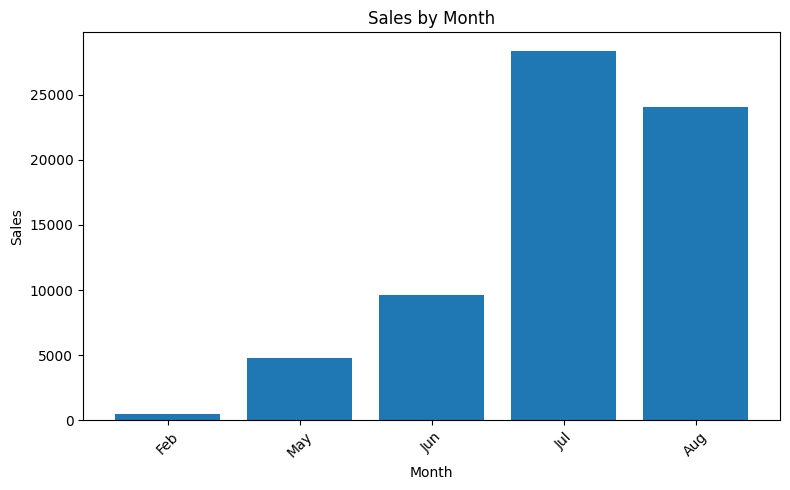

In [12]:
revenue_by_month = pd.read_sql("""SELECT d.month_name AS Month, d.month_number, SUM(fp.payment_amount) AS Sales FROM Fact_Payment fp JOIN Dim_Date d ON fp.payment_date_key = d.date_key GROUP BY d.month_name, d.month_number ORDER BY d.month_number;""", dw_engine)
plt.figure(figsize=(8,5))
plt.bar(revenue_by_month["Month"], revenue_by_month["Sales"])
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

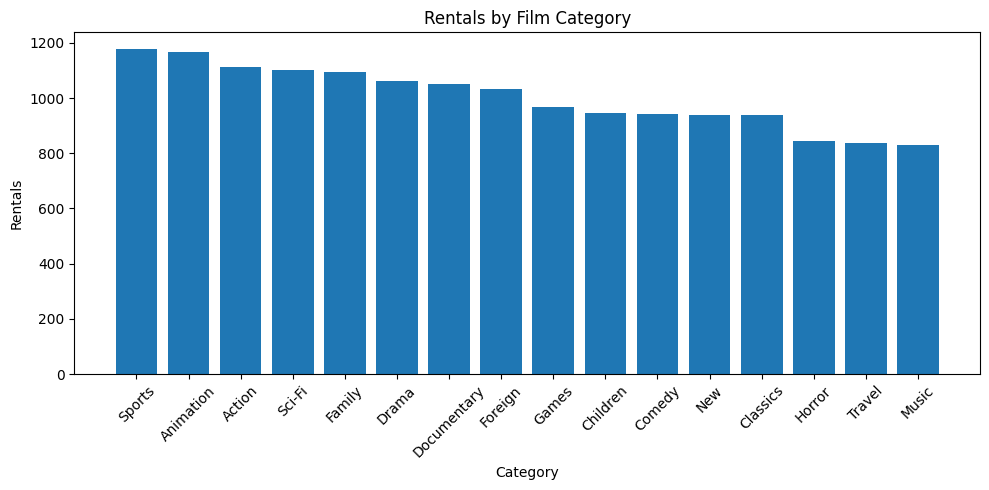

In [13]:
rentals_by_category = pd.read_sql("""SELECT f.category AS Category, COUNT(fr.rental_key) AS Rentals FROM Fact_Rental fr JOIN Dim_Film f ON fr.film_key = f.film_key GROUP BY f.category ORDER BY Rentals DESC;""", dw_engine)
plt.figure(figsize=(10,5))
plt.bar(rentals_by_category["Category"], rentals_by_category["Rentals"])
plt.title("Rentals by Film Category")
plt.xlabel("Category")
plt.ylabel("Rentals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

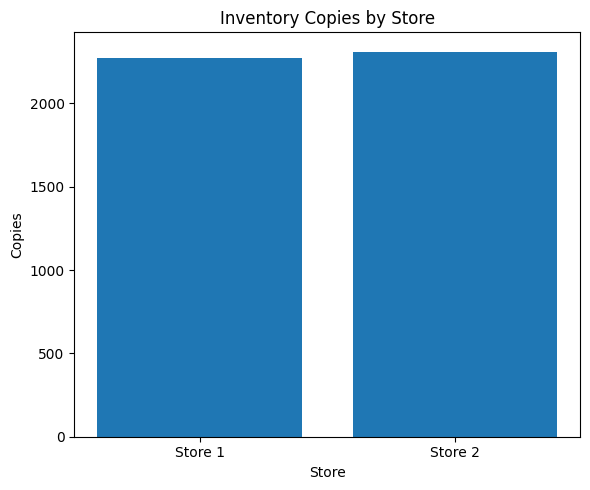

In [14]:
inventory_by_store = pd.read_sql("""SELECT CONCAT('Store ', s.store_id) AS Store, COUNT(fi.inventory_key) AS Copies FROM Fact_Inventory fi JOIN Dim_Store s ON fi.store_key = s.store_key GROUP BY s.store_id ORDER BY s.store_id;""", dw_engine)
plt.figure(figsize=(6,5))
plt.bar(inventory_by_store["Store"], inventory_by_store["Copies"])
plt.title("Inventory Copies by Store")
plt.xlabel("Store")
plt.ylabel("Copies")
plt.tight_layout()
plt.show()

## 12. Close Connections

In [15]:
source_engine.dispose()
dw_engine.dispose()
server_engine.dispose()
print("Connections closed.")

Connections closed.
